In [1]:
import os
import shutil
import zipfile
from google.colab import drive
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [2]:
# 1. Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# 2. Paste your copied path here (keep the quotes)
ZIP_PATH_IN_DRIVE = '/content/drive/MyDrive/AssignmentData/Archive (1).zip'
EXTRACT_DIR = '/content/dataset_extracted'

In [4]:
# 3. Extract Dataset
if os.path.exists(ZIP_PATH_IN_DRIVE):
    print(f"Extracting dataset from: {ZIP_PATH_IN_DRIVE}")
    with zipfile.ZipFile(ZIP_PATH_IN_DRIVE, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)
    print("Extraction complete!")
else:
    print("Error: File not found! Double-check your copied path.")

Extracting dataset from: /content/drive/MyDrive/AssignmentData/Archive (1).zip
Extraction complete!


In [5]:
# 4. Locate dataset directories
base_dir = None
for root, dirs, files in os.walk(EXTRACT_DIR):
    if 'train' in dirs and 'test' in dirs:
        base_dir = root
        break

TRAIN_DIR = os.path.join(base_dir, 'train')
VAL_DIR = os.path.join(base_dir, 'val')
TEST_DIR = os.path.join(base_dir, 'test')

In [6]:
# 5. Data Preprocessing & Generators
IMG_HEIGHT, IMG_WIDTH = 150, 150
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=15,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1.0/255.0)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=(IMG_HEIGHT, IMG_WIDTH), batch_size=BATCH_SIZE, class_mode='binary'
)
val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR, target_size=(IMG_HEIGHT, IMG_WIDTH), batch_size=BATCH_SIZE, class_mode='binary'
)
test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR, target_size=(IMG_HEIGHT, IMG_WIDTH), batch_size=BATCH_SIZE, class_mode='binary', shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [7]:
# 6. CNN Model Architecture
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dropout(0.5),
    layers.Dense(512, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), loss='binary_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
# 7. Train Model
history = model.fit(train_generator, epochs=15, validation_data=val_generator)

Epoch 1/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 84s 470ms/step - accuracy: 0.7690 - loss: 0.4996 - val_accuracy: 0.6250 - val_loss: 0.5587
Epoch 2/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 74s 454ms/step - accuracy: 0.8708 - loss: 0.2913 - val_accuracy: 0.7500 - val_loss: 0.4338
Epoch 3/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 73s 449ms/step - accuracy: 0.9116 - loss: 0.2200 - val_accuracy: 0.8750 - val_loss: 0.3965
Epoch 4/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 74s 455ms/step - accuracy: 0.9214 - loss: 0.1929 - val_accuracy: 0.8125 - val_loss: 0.4110
Epoch 5/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 73s 448ms/step - accuracy: 0.9179 - loss: 0.1960 - val_accuracy: 0.6875 - val_loss: 0.6684
Epoch 6/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 73s 448ms/step - accuracy: 0.9214 - loss: 0.2022 - val_accuracy: 0.7500 - val_loss: 0.5645
Epoch 7/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 76s 464ms/step - accuracy: 0.9281 - loss: 0.1701 - val_accuracy: 0.8125 - val_loss: 0.6541
Epoch 8/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 74s 452ms/step - accuracy: 0.9352 - loss: 0

In [9]:
# 9. Evaluate
test_loss, test_acc = model.evaluate(test_generator)
print(f"\nTest Accuracy: {test_acc * 100:.2f}%")

predictions = model.predict(test_generator)
y_pred = (predictions > 0.5).astype(int)
y_true = test_generator.classes

print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=['Normal', 'Pneumonia']))

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 249ms/step - accuracy: 0.8862 - loss: 0.3370

Test Accuracy: 88.62%
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 206ms/step

Classification Report:
               precision    recall  f1-score   support

      Normal       0.97      0.72      0.83       234
   Pneumonia       0.86      0.98      0.92       390

    accuracy                           0.89       624
   macro avg       0.91      0.85      0.87       624
weighted avg       0.90      0.89      0.88       624



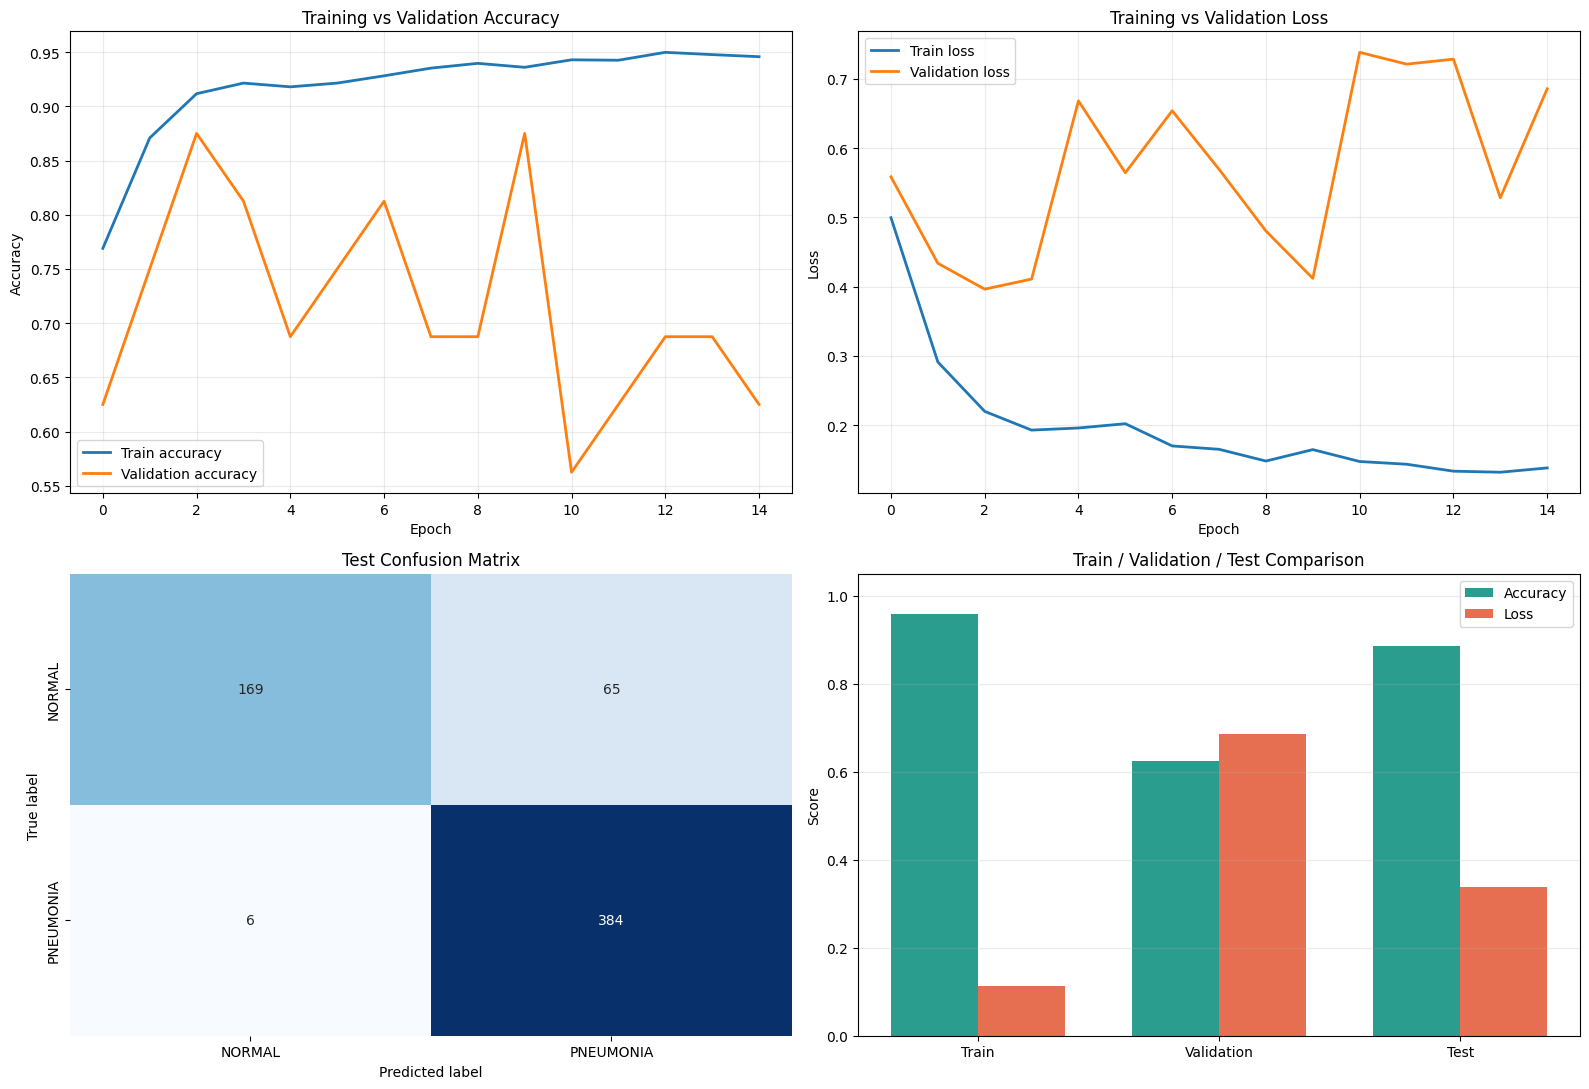

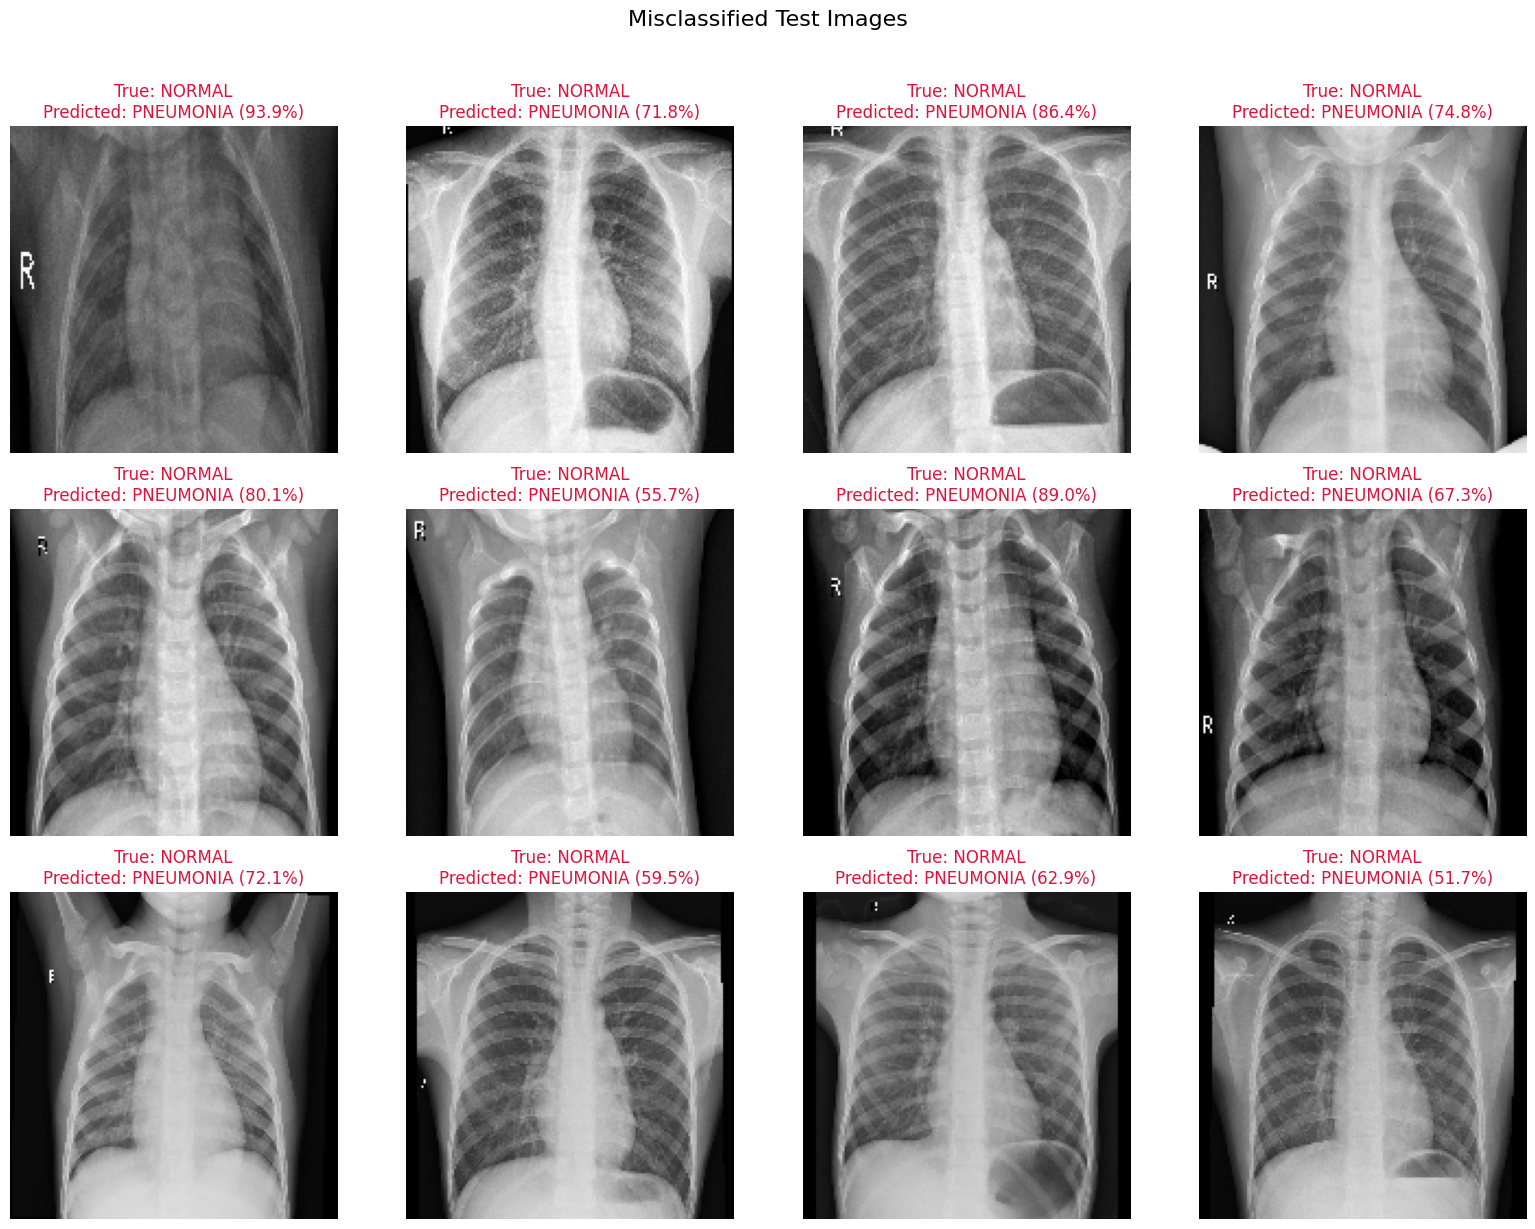

Misclassified test images: 71 / 624


In [10]:
# 10. Visualize training, validation, test performance, and misclassified images
from sklearn.metrics import ConfusionMatrixDisplay

# Class names in the same order as the model's numeric labels
class_names = [name for name, index in sorted(test_generator.class_indices.items(), key=lambda item: item[1])]

# Ensure predictions are one-dimensional for metrics and image filtering
predicted_scores = np.asarray(predictions).reshape(-1)
y_pred = (predicted_scores >= 0.5).astype(int)
y_true = np.asarray(test_generator.classes)

# Evaluate all splits for a direct comparison
train_loss, train_acc = model.evaluate(train_generator, verbose=0)
val_loss, val_acc = model.evaluate(val_generator, verbose=0)
test_loss, test_acc = model.evaluate(test_generator, verbose=0)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# Training vs validation accuracy
axes[0, 0].plot(history.history['accuracy'], label='Train accuracy', linewidth=2)
axes[0, 0].plot(history.history['val_accuracy'], label='Validation accuracy', linewidth=2)
axes[0, 0].set_title('Training vs Validation Accuracy')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Accuracy')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.25)

# Training vs validation loss
axes[0, 1].plot(history.history['loss'], label='Train loss', linewidth=2)
axes[0, 1].plot(history.history['val_loss'], label='Validation loss', linewidth=2)
axes[0, 1].set_title('Training vs Validation Loss')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.25)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[1, 0],
            xticklabels=class_names, yticklabels=class_names)
axes[1, 0].set_title('Test Confusion Matrix')
axes[1, 0].set_xlabel('Predicted label')
axes[1, 0].set_ylabel('True label')

# Accuracy and loss comparison for all splits
split_names = ['Train', 'Validation', 'Test']
accuracies = [train_acc, val_acc, test_acc]
losses = [train_loss, val_loss, test_loss]
x = np.arange(len(split_names))
bar_width = 0.36
axes[1, 1].bar(x - bar_width / 2, accuracies, bar_width, label='Accuracy', color='#2a9d8f')
axes[1, 1].bar(x + bar_width / 2, losses, bar_width, label='Loss', color='#e76f51')
axes[1, 1].set_xticks(x, split_names)
axes[1, 1].set_ylim(0, 1.05)
axes[1, 1].set_title('Train / Validation / Test Comparison')
axes[1, 1].set_ylabel('Score')
axes[1, 1].legend()
axes[1, 1].grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

# Display examples the model classified incorrectly
misclassified_indices = np.flatnonzero(y_true != y_pred)
max_images = min(12, len(misclassified_indices))

if max_images == 0:
    print('No misclassified test images found.')
else:
    columns = 4
    rows = int(np.ceil(max_images / columns))
    plt.figure(figsize=(16, 4 * rows))

    for plot_index, image_index in enumerate(misclassified_indices[:max_images], start=1):
        image = tf.keras.utils.load_img(
            test_generator.filepaths[image_index],
            target_size=(IMG_HEIGHT, IMG_WIDTH)
        )
        image_array = tf.keras.utils.img_to_array(image).astype('uint8')
        true_label = class_names[y_true[image_index]]
        predicted_label = class_names[y_pred[image_index]]
        confidence = predicted_scores[image_index] if y_pred[image_index] == 1 else 1 - predicted_scores[image_index]

        ax = plt.subplot(rows, columns, plot_index)
        ax.imshow(image_array)
        ax.set_title(
            f'True: {true_label}\nPredicted: {predicted_label} ({confidence:.1%})',
            color='crimson'
        )
        ax.axis('off')

    plt.suptitle('Misclassified Test Images', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

print(f'Misclassified test images: {len(misclassified_indices)} / {len(y_true)}')